# Model Development For Linear

I320D Final Project: Predicting Ambulance Arrival Times

---

**Part 1:** Baseline model (linear regression)

**Part 2:** Ridge

**Part 3:** Lasso

**Part 4:** Log Transform

**Part 5:** Square Root

**Part 6:** Square

In [53]:
from math import log
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import sklearn.metrics as metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from matplotlib import pyplot as plt
from google.colab import userdata
from google.colab import files
from scipy import sparse

## Preprocess Data

Extract & Clean Data

In [55]:
# import the data
df = pd.read_csv("nyc_ems_2023_2024_data.txt",
                 parse_dates=['incident_datetime', 'first_on_scene_datetime'])

In [56]:
# View df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605175 entries, 0 to 605174
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   cad_incident_id                605175 non-null  int64         
 1   incident_datetime              605175 non-null  datetime64[ns]
 2   initial_call_type              605175 non-null  object        
 3   initial_severity_level_code    605175 non-null  int64         
 4   final_call_type                605175 non-null  object        
 5   final_severity_level_code      605175 non-null  int64         
 6   first_assignment_datetime      605175 non-null  object        
 7   dispatch_response_seconds_qy   605175 non-null  int64         
 8   first_on_scene_datetime        605175 non-null  datetime64[ns]
 9   incident_response_seconds_qy   605175 non-null  int64         
 10  incident_travel_tm_seconds_qy  605174 non-null  float64       
 11  

In [57]:
df['incident_datetime'] = pd.to_datetime(df['incident_datetime'], format='mixed')
df['response_time_seconds'] = (df['first_on_scene_datetime'] - df['incident_datetime']).dt.total_seconds()
df.dropna(subset=['response_time_seconds'], inplace=True)

Feature Engineering

In [58]:
# Define a meaningful hour colum --> incident_hour (0-23)
df['incident_hour'] = df['incident_datetime'].dt.hour

# Define a meaningful day column --> incident_day_of_week (0-6)
df['incident_day_of_week'] = df['incident_datetime'].dt.dayofweek

# Define a meaningful month column --> incident_month (1-12)
df['incident_month'] = df['incident_datetime'].dt.month

In [59]:
# Indicate whether an incident occurs on a weekend
df['is_weekend'] = df['incident_day_of_week'].isin([5, 6]).astype(int)

# Indicate whether an incident occurs during rush hour
is_weekday = ~df['incident_day_of_week'].isin([5, 6])
is_morning_rush = (df['incident_hour'] >= 6) & (df['incident_hour'] <= 10)          # morning rush: 6-10AM
is_evening_rush = (df['incident_hour'] >= 16) & (df['incident_hour'] <= 20)         # evening rush: 4-8PM
df['is_rush_hour'] = ((is_morning_rush | is_evening_rush) & is_weekday).astype(int) # binary categorical

# Turn special_event_indicator into a binary numerical categorical variable
df['special_event_indicator'] = df['special_event_indicator'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

Lag & Rolling Features

In [60]:
# Create a lag feature: response time of previous incident in the same service area
df['lag_response_time'] = df.groupby('incident_dispatch_area')['response_time_seconds'].shift(1)

# For rows that don't have a previous response time, impute with overall mean response time
avg_response_time = df['response_time_seconds'].mean()
df['lag_response_time'] = df['lag_response_time'].fillna(avg_response_time)

In [61]:
# Ensure chronological order before calculating rolling avg
df = df.sort_values(by='incident_datetime').reset_index(drop=True)

# Create a rolling avg. response time feature for the past 3 hours
df['rolling_avg_response_time_3h'] = (df
    .groupby('incident_dispatch_area', observed=True)            # group by dispatch area
    [['incident_datetime', 'response_time_seconds']]             # select both columns
    .rolling(window='3h', on='incident_datetime', closed='left') # 3hr window <-- we can change this to a different value too
    .mean()                                                      # calculate avg
    ['response_time_seconds'] # use the response_time_seconds column from the result
    .reset_index(level=0, drop=True)
)

# For rows that don't have 3hr of previous data, impute with overall mean response time
df['rolling_avg_response_time_3h'] = df['rolling_avg_response_time_3h'].fillna(avg_response_time)

In [62]:
# Create a lagged incident count feature for the past 15 minutes
df['lag_incident_count_15min'] = (df
    .groupby('incident_dispatch_area', observed=True)               # group by dispatch are
    .rolling(window='15min', on='incident_datetime', closed='left') # 15min window <-- we can change this to a different value too
    .count()                                                        # calculate total count
    ['cad_incident_id'] # use the count for cad_incident_id (ensures integer type)
    .reset_index(level=0, drop=True)
)

# For rows that don't have any incidents within the last 15min - impute NaN with 0 and ensure integer type
df['lag_incident_count_15min'] = df['lag_incident_count_15min'].fillna(0).astype(int)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605175 entries, 0 to 605174
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   cad_incident_id                605175 non-null  int64         
 1   incident_datetime              605175 non-null  datetime64[ns]
 2   initial_call_type              605175 non-null  object        
 3   initial_severity_level_code    605175 non-null  int64         
 4   final_call_type                605175 non-null  object        
 5   final_severity_level_code      605175 non-null  int64         
 6   first_assignment_datetime      605175 non-null  object        
 7   dispatch_response_seconds_qy   605175 non-null  int64         
 8   first_on_scene_datetime        605175 non-null  datetime64[ns]
 9   incident_response_seconds_qy   605175 non-null  int64         
 10  incident_travel_tm_seconds_qy  605174 non-null  float64       
 11  

In [64]:
df.head()

,cad_incident_id,incident_datetime,initial_call_type,initial_severity_level_code,final_call_type,final_severity_level_code,first_assignment_datetime,dispatch_response_seconds_qy,first_on_scene_datetime,incident_response_seconds_qy,...,special_event_indicator,response_time_seconds,incident_hour,incident_day_of_week,incident_month,is_weekend,is_rush_hour,lag_response_time,rolling_avg_response_time_3h,lag_incident_count_15min
0,230010003,2023-01-01 00:00:30,DIFFFC,2,DIFFFC,2,2023-01-01 00:02:24,114,2023-01-01 00:08:29,479,...,0,479.0,0,6,1,1,0,532.244936,532.244936,0
1,230010004,2023-01-01 00:01:35,INJURY,5,INJURY,5,2023-01-01 01:03:40,3725,2023-01-01 01:03:40,3725,...,0,3725.0,0,6,1,1,0,532.244936,532.244936,0
2,230010011,2023-01-01 00:03:22,UNC,2,UNC,2,2023-01-01 00:08:20,298,2023-01-01 00:21:37,1095,...,0,1095.0,0,6,1,1,0,532.244936,532.244936,0
3,230010012,2023-01-01 00:03:37,UNC,2,DRUG,4,2023-01-01 00:23:48,1211,2023-01-01 00:46:52,2595,...,0,2595.0,0,6,1,1,0,1095.000000,1095.000000,1
4,230010013,2023-01-01 00:03:53,SICK,6,SICK,6,2023-01-01 00:04:17,24,2023-01-01 00:14:46,653,...,0,653.0,0,6,1,1,0,532.244936,532.244936,0


## Part 1: Baseline Model

*   Spli the target varible and features
*   Scale (MinMax or Standard)
*   Split Data
*   Apply Model




Select target variable and features; one-hot encode categorical features

In [65]:
# Numerical features (continuous)
numerical_features = [
    'initial_severity_level_code',
    'lag_response_time',
    'rolling_avg_response_time_3h',
    'lag_incident_count_15min'
]

# Additional numeric engineered features
numerical_features += [
    'incident_hour',
    'incident_day_of_week',
    'incident_month'
]

# Binary numeric features
binary_numeric_features = [
    'is_weekend',
    'is_rush_hour',
    'special_event_indicator'
]

# Categorical features (these need one-hot encoding)
categorical_features = [
    'initial_call_type',
    'borough',
    'incident_dispatch_area',
    'zipcode'
]

# Combine all features
all_features = numerical_features + binary_numeric_features + categorical_features
features_df = df[all_features].copy()
target_variable_df = df[['incident_travel_tm_seconds_qy']]


## Feature Types Summary

Here's a breakdown of the features used, categorized by their type:

| Feature Type       | Features                                                                                                                                                                                                                                   |
|:-------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Numerical**      | `initial_severity_level_code`, `lag_response_time`, `rolling_avg_response_time_3h`, `lag_incident_count_15min`, `incident_hour`, `incident_day_of_week`, `incident_month`                                                                   |
| **Binary**         | `is_weekend`, `is_rush_hour`, `special_event_indicator`                                                                                                                                                                                    |
| **Categorical**    | `initial_call_type`, `borough`, `incident_dispatch_area`, `zipcode`                                                                                                                                                                        |

In [66]:
# Combine all selected features
all_features = numerical_features + binary_numeric_features + categorical_features
features_df = df[all_features].copy()

# Update features_columns and target_variable_columns for clarity
features_columns = all_features
target_variable_columns = list(target_variable_df.columns)

Split, scale, encode data

In [67]:
# Split the data into 80% train and 20% "holder data"
x_train_raw, x_main_raw, y_train, y_main = train_test_split(features_df, target_variable_df, test_size=0.20, random_state=42)

# Split the "holder data" into 10% for test and 10% validation
x_val_raw, x_test_raw, y_val, y_test = train_test_split(x_main_raw, y_main, test_size=0.50, random_state=42)

In [68]:
# Manual Scaling for Numerical Features (using raw data as there are no NaNs)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_raw[numerical_features])
x_val_scaled = scaler.transform(x_val_raw[numerical_features])
x_test_scaled = scaler.transform(x_test_raw[numerical_features])

In [69]:
# Manual One-Hot Encoding for Categorical Features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output = True)
x_train_encoded = encoder.fit_transform(x_train_raw[categorical_features])
x_val_encoded = encoder.transform(x_val_raw[categorical_features])
x_test_encoded = encoder.transform(x_test_raw[categorical_features])

In [70]:
# Concatenate processed numerical and categorical features
x_train_processed = np.hstack((x_train_scaled, x_train_encoded.toarray()))
x_val_processed = np.hstack((x_val_scaled, x_val_encoded.toarray()))
x_test_processed = np.hstack((x_test_scaled, x_test_encoded.toarray()))

# Printing of shapes for validation
print (f"Training: Features' shape =  {x_train_processed.shape}")
print (f"Training: Label's shape = {y_train.shape}")

print (f"Validation: Features' shape =  {x_val_processed.shape}")
print (f"Validation: Label's shape = {y_val.shape}")

print (f"Test: Features' shape =  {x_test_processed.shape}")
print (f"Test: Label's shape = {y_test.shape}")

Training: Features' shape =  (484140, 415)
Training: Label's shape = (484140, 1)
Validation: Features' shape =  (60517, 415)
Validation: Label's shape = (60517, 1)
Test: Features' shape =  (60518, 415)
Test: Label's shape = (60518, 1)


## Linear Regression Base Model

In [71]:
# Train Linear Regression model
regression_model = LinearRegression()

# Training
regression = regression_model.fit(x_train_processed, y_train.to_numpy().flatten())
print ("Training complete")

Training complete


In [72]:
# Perform prediction on test data
y_test_predicted = regression_model.predict(x_test_processed)

# Calcuatling prefomance meterics
mean_squared_error=metrics.mean_squared_error(y_test, y_test_predicted)
mean_absolute_error=metrics.mean_absolute_error(y_test, y_test_predicted)
correlation = pearsonr(y_test.to_numpy().flatten(), y_test_predicted.flatten())

# Printing the meterics
print (f"Linear Regressor: Mean Squared Error = {mean_squared_error:.3f}")
print (f"Linear Regressor: Mean Absolute Error = {mean_absolute_error:.3f}")
print (f"Pearson correlation coefficient between actual and predicted values is {correlation}")

Linear Regressor: Mean Squared Error = 88496.365
Linear Regressor: Mean Absolute Error = 201.964
Pearson correlation coefficient between actual and predicted values is PearsonRResult(statistic=np.float64(0.3865584878146341), pvalue=np.float64(0.0))


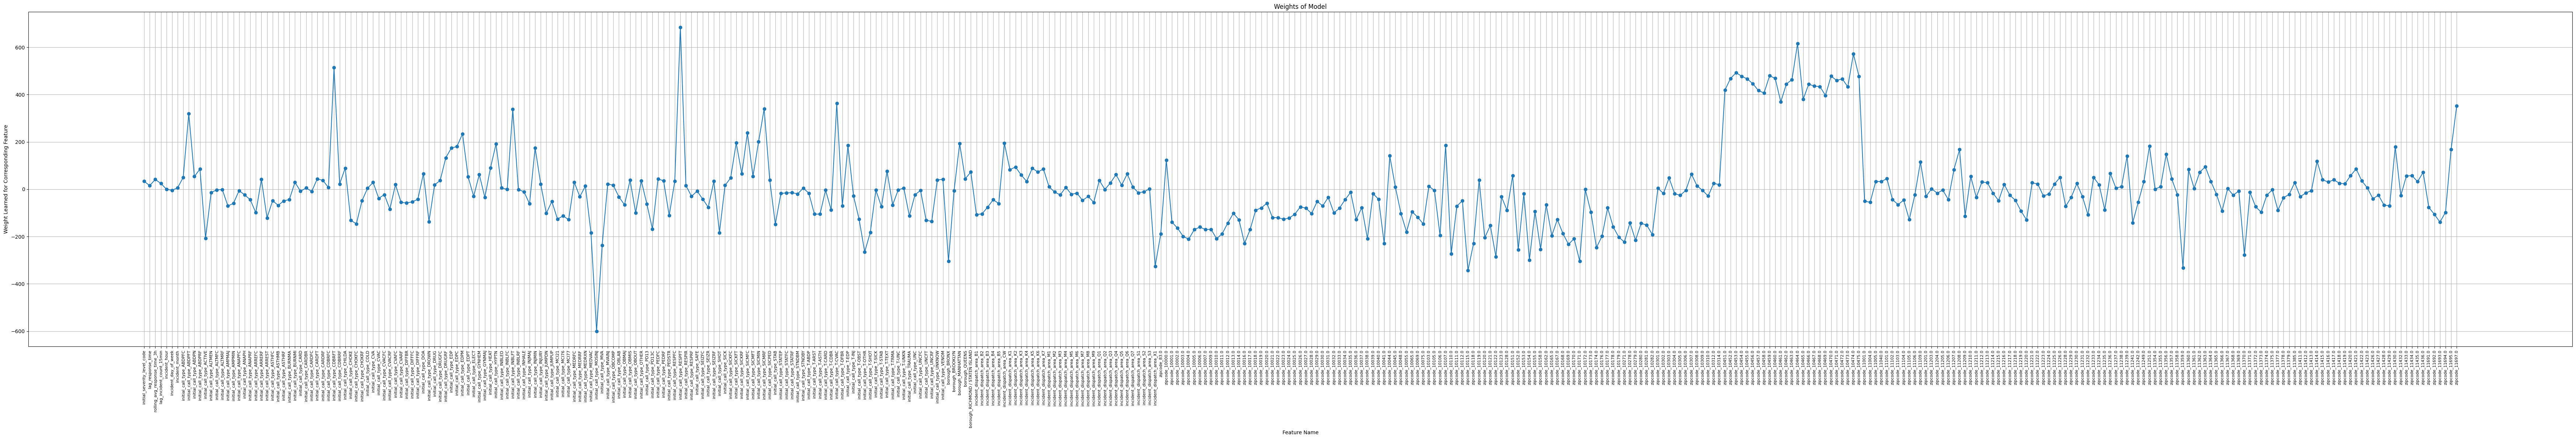

In [73]:
# Retriving the weights from the model
weights = regression_model.coef_

# Get feature names after one-hot encoding from the fitted encoder
# The order of features will be numerical features first, then one-hot encoded categorical features.
feature_names_out = numerical_features + list(encoder.get_feature_names_out(categorical_features))

# Ploting all the weights into a plot
plt.figure(figsize=(70,12)) # Increase figure size to accommodate more labels
plt.plot(range(len(weights)), weights, marker='o')
plt.xticks(range(len(weights)), feature_names_out, rotation=90, fontsize=8) # Rotate labels and adjust font size
plt.title('Weights of Model')
plt.xlabel("Feature Name")
plt.ylabel("Weight Learned for Corresponding Feature")
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

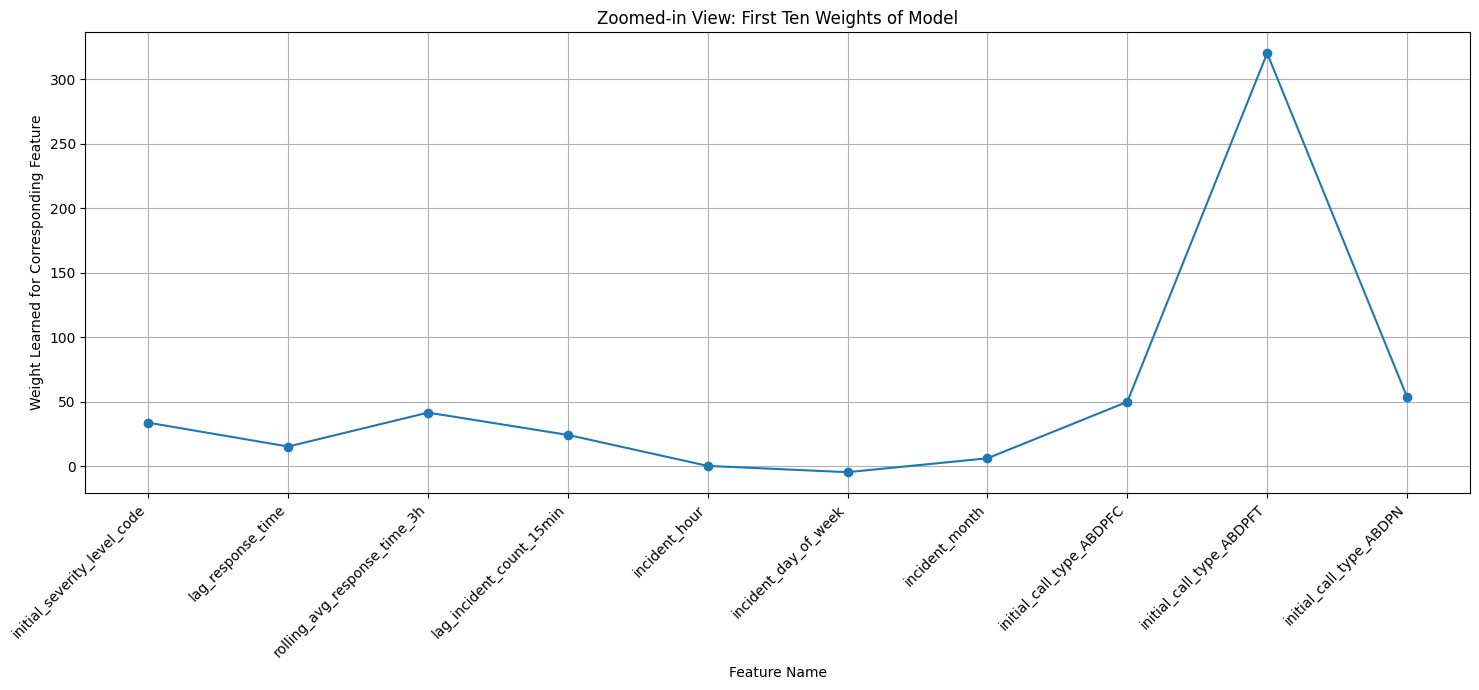

In [74]:
# Ploting the first ten weights into a zoomed-in plot
plt.figure(figsize=(15, 7)) # Adjust figure size for better visibility of 10 labels
plt.plot(range(10), weights[:10], marker='o')
plt.xticks(range(10), feature_names_out[:10], rotation=45, ha='right', fontsize=10) # Rotate labels and adjust font size
plt.title('Zoomed-in View: First Ten Weights of Model')
plt.xlabel("Feature Name")
plt.ylabel("Weight Learned for Corresponding Feature")
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Train and Evaluate Ridge Regression


In [ ]:
from sklearn.linear_model import Ridge

# 1. Instantiate a Ridge regression model with default alpha (1.0)
ridge_model = Ridge(alpha=1.0)

# 2. Fit the Ridge model to the training data
ridge_model.fit(x_train_processed, y_train.to_numpy().flatten())
print("Ridge Regression model trained.")

# 3. Use the trained Ridge model to make predictions on the test data
y_test_predicted_ridge = ridge_model.predict(x_test_processed)

# 4. Calculate the Mean Squared Error (MSE)
mse_ridge = metrics.mean_squared_error(y_test, y_test_predicted_ridge)

# 5. Calculate the Mean Absolute Error (MAE)
mae_ridge = metrics.mean_absolute_error(y_test, y_test_predicted_ridge)

# 6. Calculate the Pearson correlation coefficient
correlation_ridge = pearsonr(y_test.to_numpy().flatten(), y_test_predicted_ridge.flatten())

# 7. Print the calculated metrics
print(f"\nRidge Regressor: Mean Squared Error = {mse_ridge:.3f}")
print(f"Ridge Regressor: Mean Absolute Error = {mae_ridge:.3f}")
print(f"Pearson correlation coefficient between actual and predicted values for Ridge is {correlation_ridge}")

Ridge Regression model trained.

Ridge Regressor: Mean Squared Error = 88487.595
Ridge Regressor: Mean Absolute Error = 201.952
Pearson correlation coefficient between actual and predicted values for Ridge is PearsonRResult(statistic=np.float64(0.3866677461709719), pvalue=np.float64(0.0))


## Train and Evaluate Lasso Regression


In [ ]:
from sklearn.linear_model import Lasso

# 1. Instantiate a Lasso regression model with default alpha (1.0)
lasso_model = Lasso(alpha=1.0)

# 2. Fit the Lasso model to the training data
lasso_model.fit(x_train_processed, y_train.to_numpy().flatten())
print("Lasso Regression model trained.")

# 3. Use the trained Lasso model to make predictions on the test data
y_test_predicted_lasso = lasso_model.predict(x_test_processed)

# 4. Calculate the Mean Squared Error (MSE)
mse_lasso = metrics.mean_squared_error(y_test, y_test_predicted_lasso)

# 5. Calculate the Mean Absolute Error (MAE)
mae_lasso = metrics.mean_absolute_error(y_test, y_test_predicted_lasso)

# 6. Calculate the Pearson correlation coefficient
correlation_lasso = pearsonr(y_test.to_numpy().flatten(), y_test_predicted_lasso.flatten())

# 7. Print the calculated MSE, MAE, and Pearson correlation coefficient
print(f"\nLasso Regressor: Mean Squared Error = {mse_lasso:.3f}")
print(f"Lasso Regressor: Mean Absolute Error = {mae_lasso:.3f}")
print(f"Pearson correlation coefficient between actual and predicted values for Lasso is {correlation_lasso}")

Lasso Regression model trained.

Lasso Regressor: Mean Squared Error = 91387.945
Lasso Regressor: Mean Absolute Error = 206.212
Pearson correlation coefficient between actual and predicted values for Lasso is PearsonRResult(statistic=np.float64(0.3493299659750019), pvalue=np.float64(0.0))


## Log Transform Target Variable



In [ ]:
import numpy as np

# 1. Apply np.log1p to y_train, y_val, and y_test
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# 2. Instantiate a LinearRegression model
regression_model_log = LinearRegression()

# 3. Fit the LinearRegression model using x_train_processed and y_train_log
regression_log = regression_model_log.fit(x_train_processed, y_train_log.to_numpy().flatten())
print("Linear Regression model trained with log-transformed target.")

# 4. Make predictions on x_test_processed
y_test_predicted_log_transformed = regression_model_log.predict(x_test_processed)

# 5. Apply np.expm1 to inverse transform the predictions
y_test_predicted_log_inverse_transformed = np.expm1(y_test_predicted_log_transformed)

# 6. Calculate the Mean Squared Error (MSE)
mse_log = metrics.mean_squared_error(y_test, y_test_predicted_log_inverse_transformed)

# 7. Calculate the Mean Absolute Error (MAE)
mae_log = metrics.mean_absolute_error(y_test, y_test_predicted_log_inverse_transformed)

# 8. Calculate the Pearson correlation coefficient
correlation_log = pearsonr(y_test.to_numpy().flatten(), y_test_predicted_log_inverse_transformed.flatten())

# 9. Print the calculated MSE, MAE, and Pearson correlation coefficient
print(f"\nLinear Regressor (Log-Transformed Target): Mean Squared Error = {mse_log:.3f}")
print(f"Linear Regressor (Log-Transformed Target): Mean Absolute Error = {mae_log:.3f}")
print(f"Pearson correlation coefficient between actual and predicted values (Log-Transformed Target) is {correlation_log}")

Linear Regression model trained with log-transformed target.

Linear Regressor (Log-Transformed Target): Mean Squared Error = 97546.984
Linear Regressor (Log-Transformed Target): Mean Absolute Error = 198.391
Pearson correlation coefficient between actual and predicted values (Log-Transformed Target) is PearsonRResult(statistic=np.float64(0.3722713833431828), pvalue=np.float64(0.0))


## Square Root Transform Target Variable


In [ ]:
import numpy as np

# 1. Apply np.sqrt to y_train, y_val, and y_test
y_train_sqrt = np.sqrt(y_train)
y_val_sqrt = np.sqrt(y_val)
y_test_sqrt = np.sqrt(y_test)

# 2. Instantiate a new LinearRegression model
regression_model_sqrt = LinearRegression()

# 3. Fit the LinearRegression model using x_train_processed and y_train_sqrt
regression_sqrt = regression_model_sqrt.fit(x_train_processed, y_train_sqrt.to_numpy().flatten())
print("Linear Regression model trained with square root-transformed target.")

# 4. Make predictions on x_test_processed
y_test_predicted_sqrt_transformed = regression_model_sqrt.predict(x_test_processed)

# 5. Apply np.square to inverse transform the predictions
y_test_predicted_sqrt_inverse_transformed = np.square(y_test_predicted_sqrt_transformed)

# 6. Calculate the Mean Squared Error (MSE)
mse_sqrt = metrics.mean_squared_error(y_test, y_test_predicted_sqrt_inverse_transformed)

# 7. Calculate the Mean Absolute Error (MAE)
mae_sqrt = metrics.mean_absolute_error(y_test, y_test_predicted_sqrt_inverse_transformed)

# 8. Calculate the Pearson correlation coefficient
correlation_sqrt = pearsonr(y_test.to_numpy().flatten(), y_test_predicted_sqrt_inverse_transformed.flatten())

# 9. Print the calculated MSE, MAE, and Pearson correlation coefficient
print(f"\nLinear Regressor (Square Root-Transformed Target): Mean Squared Error = {mse_sqrt:.3f}")
print(f"Linear Regressor (Square Root-Transformed Target): Mean Absolute Error = {mae_sqrt:.3f}")
print(f"Pearson correlation coefficient between actual and predicted values (Square Root-Transformed Target) is {correlation_sqrt}")

Linear Regression model trained with square root-transformed target.

Linear Regressor (Square Root-Transformed Target): Mean Squared Error = 89857.372
Linear Regressor (Square Root-Transformed Target): Mean Absolute Error = 196.297
Pearson correlation coefficient between actual and predicted values (Square Root-Transformed Target) is PearsonRResult(statistic=np.float64(0.38978976980224966), pvalue=np.float64(0.0))


## Square Transform Target Variable



In [ ]:
import numpy as np

# 1. Apply np.square to y_train, y_val, and y_test
y_train_square = np.square(y_train)
y_val_square = np.square(y_val)
y_test_square = np.square(y_test)

# 2. Instantiate a new LinearRegression model
regression_model_square = LinearRegression()

# 3. Fit the LinearRegression model using x_train_processed and y_train_square
regression_square = regression_model_square.fit(x_train_processed, y_train_square.to_numpy().flatten())
print("Linear Regression model trained with square-transformed target.")

# 4. Make predictions on x_test_processed
y_test_predicted_square_transformed = regression_model_square.predict(x_test_processed)

# 5. Apply np.sqrt to inverse transform the predictions, ensuring values are non-negative
y_test_predicted_square_inverse_transformed = np.sqrt(np.maximum(0, y_test_predicted_square_transformed))

# 6. Calculate the Mean Squared Error (MSE)
mse_square = metrics.mean_squared_error(y_test, y_test_predicted_square_inverse_transformed)

# 7. Calculate the Mean Absolute Error (MAE)
mae_square = metrics.mean_absolute_error(y_test, y_test_predicted_square_inverse_transformed)

# 8. Calculate the Pearson correlation coefficient
correlation_square = pearsonr(y_test.to_numpy().flatten(), y_test_predicted_square_inverse_transformed.flatten())

# 9. Print the calculated MSE, MAE, and Pearson correlation coefficient
print(f"\nLinear Regressor (Square-Transformed Target): Mean Squared Error = {mse_square:.3f}")
print(f"Linear Regressor (Square-Transformed Target): Mean Absolute Error = {mae_square:.3f}")
print(f"Pearson correlation coefficient between actual and predicted values (Square-Transformed Target) is {correlation_square}")

Linear Regression model trained with square-transformed target.

Linear Regressor (Square-Transformed Target): Mean Squared Error = 99859.606
Linear Regressor (Square-Transformed Target): Mean Absolute Error = 233.529
Pearson correlation coefficient between actual and predicted values (Square-Transformed Target) is PearsonRResult(statistic=np.float64(0.3567849827358972), pvalue=np.float64(0.0))


## Model Performance Comparison: MSE, MAE, and Pearson Correlation

| Model                                  | MSE       | MAE       | Pearson Correlation |
|:---------------------------------------|:----------|:----------|:--------------------|
| **Baseline Linear Regression**         | 88496.365 | 201.964   | 0.387               |
| **Ridge Regression**                   | 88487.595 | 201.952   | 0.387               |
| **Lasso Regression**                   | 91387.945 | 206.212   | 0.349               |
| **Log-transformed Linear Regression**  | 97546.984 | 198.391   | 0.372               |
| **Square Root-transformed Linear Regression** | 89857.372 | 196.297   | 0.390               |
| **Square-transformed Linear Regression** | 99859.606 | 233.529   | 0.357               |

## Prepare Evaluation Functions


In [ ]:
import numpy as np
from sklearn import metrics

# 1. Define Adjusted R-squared function
def adjusted_r_squared(y_true, y_pred, num_features):
    r2 = metrics.r2_score(y_true, y_pred)
    n = len(y_true)
    # Ensure n - num_features - 1 is not zero to avoid division error
    if (n - num_features - 1) == 0:
        return np.nan # Or handle as appropriate, e.g., raise an error
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - num_features - 1)
    return adj_r2

# 2. Define Mean Absolute Percentage Error (MAPE) function
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Filter out instances where y_true is zero to avoid division by zero
    non_zero_indices = y_true != 0
    y_true_filtered = y_true[non_zero_indices]
    y_pred_filtered = y_pred[non_zero_indices]

    if len(y_true_filtered) == 0:
        return np.nan # No valid instances to calculate MAPE

    mape = np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_filtered)) * 100
    return mape

print("Custom evaluation functions 'adjusted_r_squared' and 'mean_absolute_percentage_error' defined.")

Custom evaluation functions 'adjusted_r_squared' and 'mean_absolute_percentage_error' defined.


## Evaluate Baseline Linear Regression


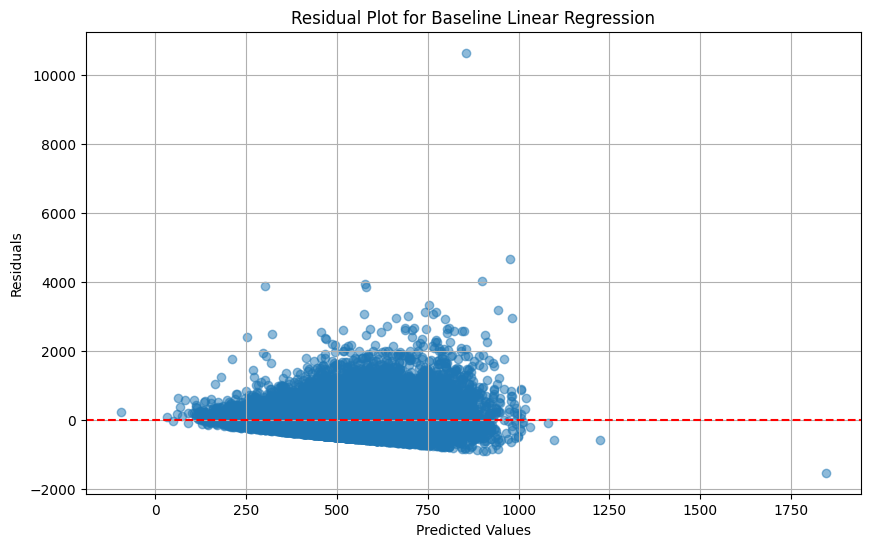


--- Baseline Linear Regression Model Evaluation ---
R-squared (R²): 0.149
Adjusted R-squared (Adj. R²): 0.144
Root Mean Squared Error (RMSE): 297.483
Mean Absolute Percentage Error (MAPE): 70.850%
Durbin-Watson Statistic: 2.008


In [ ]:
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

# 1. Calculate the R-squared score
r2_baseline = metrics.r2_score(y_test, y_test_predicted)

# 2. Calculate the Adjusted R-squared
# num_features for the baseline model is the number of columns in x_test_processed
num_features_baseline = x_test_processed.shape[1]
adj_r2_baseline = adjusted_r_squared(y_test.to_numpy().flatten(), y_test_predicted, num_features_baseline)

# 3. Calculate the Root Mean Squared Error (RMSE)
rmse_baseline = np.sqrt(mean_squared_error)

# 4. Calculate the Mean Absolute Percentage Error (MAPE)
mape_baseline = mean_absolute_percentage_error(y_test.to_numpy().flatten(), y_test_predicted)

# 5. Calculate the residuals
residuals_baseline = y_test.to_numpy().flatten() - y_test_predicted

# 6. Generate a scatter plot of the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test_predicted, residuals_baseline, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Baseline Linear Regression')
plt.grid(True)
plt.show()

# 8. Calculate the Durbin-Watson statistic
dw_statistic_baseline = durbin_watson(residuals_baseline)

# 9. Print all calculated metrics
print(f"\n--- Baseline Linear Regression Model Evaluation ---")
print(f"R-squared (R²): {r2_baseline:.3f}")
print(f"Adjusted R-squared (Adj. R²): {adj_r2_baseline:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_baseline:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_baseline:.3f}%")
print(f"Durbin-Watson Statistic: {dw_statistic_baseline:.3f}")


## Evaluate Ridge Regression


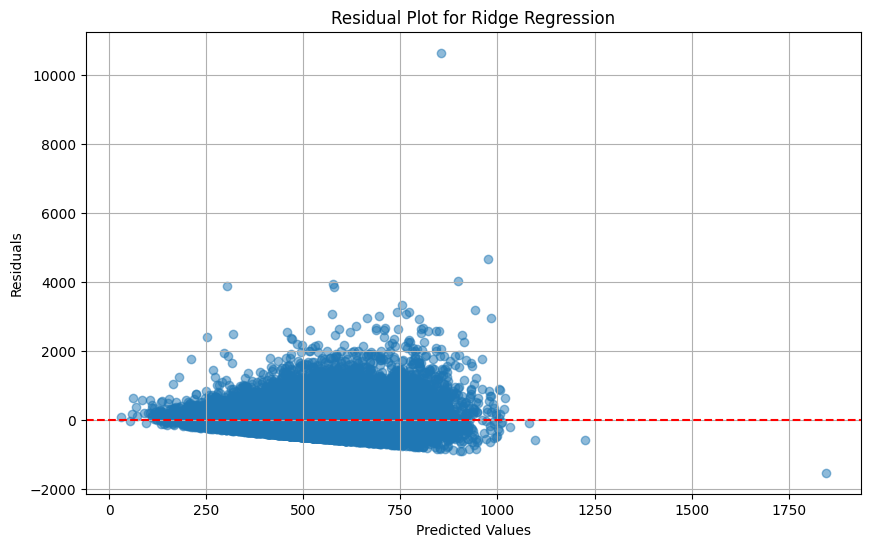


--- Ridge Regression Model Evaluation ---
R-squared (R²): 0.150
Adjusted R-squared (Adj. R²): 0.144
Root Mean Squared Error (RMSE): 297.469
Mean Absolute Percentage Error (MAPE): 70.849%


In [ ]:
# 1. Calculate the R-squared score for the Ridge model
r2_ridge = metrics.r2_score(y_test, y_test_predicted_ridge)

# 2. Calculate the Adjusted R-squared for the Ridge model
num_features_ridge = x_test_processed.shape[1] # Number of features is the same as baseline
adj_r2_ridge = adjusted_r_squared(y_test.to_numpy().flatten(), y_test_predicted_ridge, num_features_ridge)

# 3. Calculate the Root Mean Squared Error (RMSE) for the Ridge model
rmse_ridge = np.sqrt(mse_ridge)

# 4. Calculate the Mean Absolute Percentage Error (MAPE) for the Ridge model
mape_ridge = mean_absolute_percentage_error(y_test.to_numpy().flatten(), y_test_predicted_ridge)

# 5. Calculate the residuals for the Ridge model
residuals_ridge = y_test.to_numpy().flatten() - y_test_predicted_ridge

# 6. Generate a scatter plot of the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test_predicted_ridge, residuals_ridge, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Ridge Regression')
plt.grid(True)
plt.show()

# 7. Print all calculated metrics for the Ridge Regression model
print(f"\n--- Ridge Regression Model Evaluation ---")
print(f"R-squared (R²): {r2_ridge:.3f}")
print(f"Adjusted R-squared (Adj. R²): {adj_r2_ridge:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_ridge:.3f}%")

## Evaluate Lasso Regression


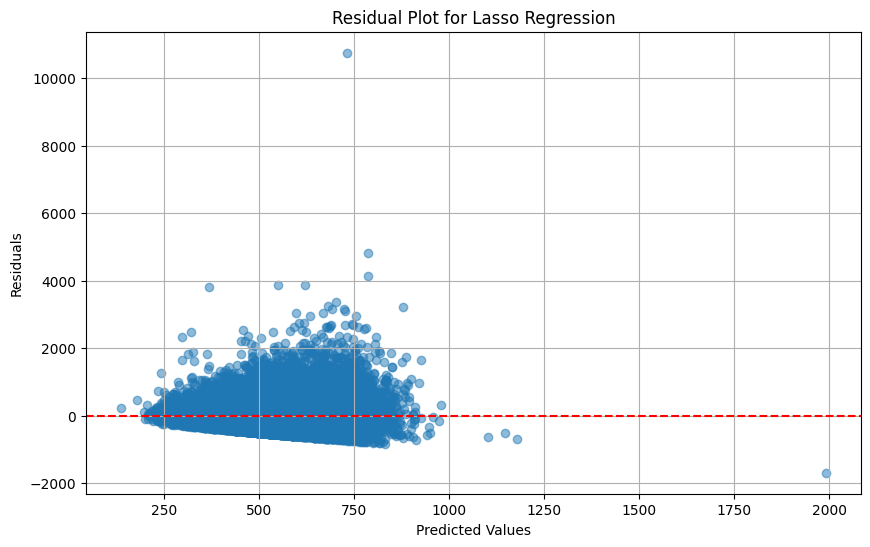


--- Lasso Regression Model Evaluation ---
R-squared (R²): 0.122
Adjusted R-squared (Adj. R²): 0.116
Root Mean Squared Error (RMSE): 302.304
Mean Absolute Percentage Error (MAPE): 73.138%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

# 1. Calculate the R-squared score for the Lasso model
r2_lasso = metrics.r2_score(y_test, y_test_predicted_lasso)

# 2. Calculate the Adjusted R-squared for the Lasso model
num_features_lasso = x_test_processed.shape[1] # Number of features is the same as baseline and Ridge
adj_r2_lasso = adjusted_r_squared(y_test.to_numpy().flatten(), y_test_predicted_lasso, num_features_lasso)

# 3. Calculate the Root Mean Squared Error (RMSE) for the Lasso model
rmse_lasso = np.sqrt(mse_lasso)

# 4. Calculate the Mean Absolute Percentage Error (MAPE) for the Lasso model
mape_lasso = mean_absolute_percentage_error(y_test.to_numpy().flatten(), y_test_predicted_lasso)

# 5. Calculate the residuals for the Lasso model
residuals_lasso = y_test.to_numpy().flatten() - y_test_predicted_lasso

# 6. Generate a scatter plot of the residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test_predicted_lasso, residuals_lasso, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Lasso Regression')
plt.grid(True)
plt.show()

# 7. Print all calculated metrics for the Lasso Regression model
print(f"\n--- Lasso Regression Model Evaluation ---")
print(f"R-squared (R²): {r2_lasso:.3f}")
print(f"Adjusted R-squared (Adj. R²): {adj_r2_lasso:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lasso:.3f}%")

## Log-Transformed Linear Regression Evaluation

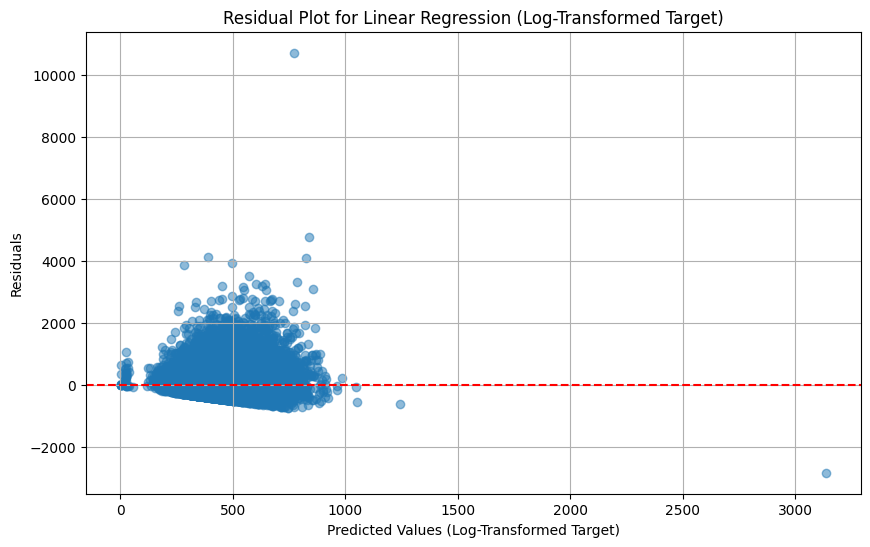


--- Linear Regression (Log-Transformed Target) Model Evaluation ---
R-squared (R²): 0.062
Adjusted R-squared (Adj. R²): 0.056
Root Mean Squared Error (RMSE): 312.325
Mean Absolute Error (MAE): 198.391
Pearson correlation coefficient: 0.372
Mean Absolute Percentage Error (MAPE): 58.056%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

# Ensure num_features_all is defined, if not already
# (Assuming x_test_processed is available from previous steps)
num_features_all = x_test_processed.shape[1]

# --- Metrics for Log-Transformed LR ---
r2_log = metrics.r2_score(y_test, y_test_predicted_log_inverse_transformed)
adj_r2_log = adjusted_r_squared(y_test.to_numpy().flatten(), y_test_predicted_log_inverse_transformed, num_features_all)
rmse_log = np.sqrt(mse_log)
mape_log = mean_absolute_percentage_error(y_test.to_numpy().flatten(), y_test_predicted_log_inverse_transformed)

# Calculate residuals for log-transformed model
residuals_log = y_test.to_numpy().flatten() - y_test_predicted_log_inverse_transformed

# Generate residual plot for log-transformed model
plt.figure(figsize=(10, 6))
plt.scatter(y_test_predicted_log_inverse_transformed, residuals_log, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (Log-Transformed Target)')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression (Log-Transformed Target)')
plt.grid(True)
plt.show()

print(f"\n--- Linear Regression (Log-Transformed Target) Model Evaluation ---")
print(f"R-squared (R²): {r2_log:.3f}")
print(f"Adjusted R-squared (Adj. R²): {adj_r2_log:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_log:.3f}")
print(f"Mean Absolute Error (MAE): {mae_log:.3f}")
print(f"Pearson correlation coefficient: {correlation_log.statistic:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_log:.3f}%")

## Square Root-Transformed Linear Regression Evaluation

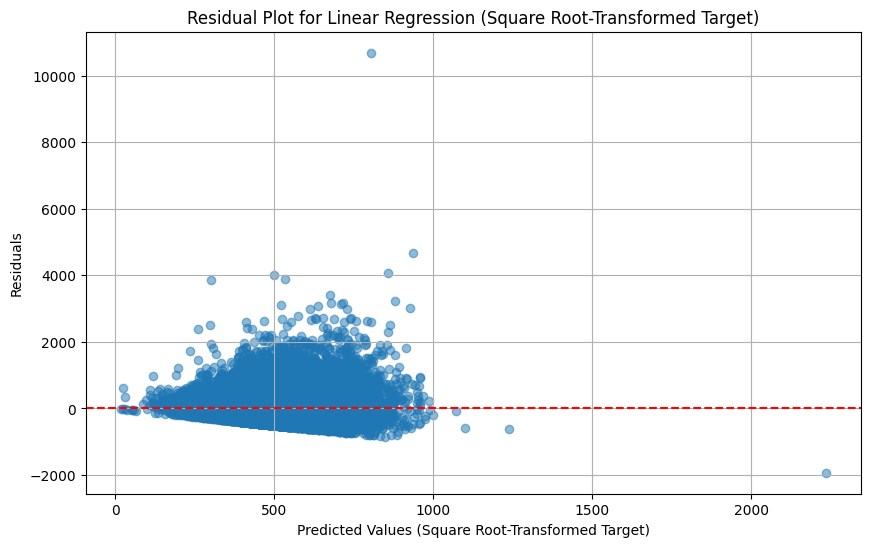


--- Linear Regression (Square Root-Transformed Target) Model Evaluation ---
R-squared (R²): 0.136
Adjusted R-squared (Adj. R²): 0.130
Root Mean Squared Error (RMSE): 299.762
Mean Absolute Error (MAE): 196.297
Pearson correlation coefficient: 0.390
Mean Absolute Percentage Error (MAPE): 64.382%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

# Ensure num_features_all is defined, if not already
# (Assuming x_test_processed is available from previous steps)
num_features_all = x_test_processed.shape[1]

# --- Metrics for Square Root-Transformed LR ---
r2_sqrt = metrics.r2_score(y_test, y_test_predicted_sqrt_inverse_transformed)
adj_r2_sqrt = adjusted_r_squared(y_test.to_numpy().flatten(), y_test_predicted_sqrt_inverse_transformed, num_features_all)
rmse_sqrt = np.sqrt(mse_sqrt)
mape_sqrt = mean_absolute_percentage_error(y_test.to_numpy().flatten(), y_test_predicted_sqrt_inverse_transformed)

# Calculate residuals for square root-transformed model
residuals_sqrt = y_test.to_numpy().flatten() - y_test_predicted_sqrt_inverse_transformed

# Generate residual plot for square root-transformed model
plt.figure(figsize=(10, 6))
plt.scatter(y_test_predicted_sqrt_inverse_transformed, residuals_sqrt, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (Square Root-Transformed Target)')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression (Square Root-Transformed Target)')
plt.grid(True)
plt.show()

print(f"\n--- Linear Regression (Square Root-Transformed Target) Model Evaluation ---")
print(f"R-squared (R²): {r2_sqrt:.3f}")
print(f"Adjusted R-squared (Adj. R²): {adj_r2_sqrt:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sqrt:.3f}")
print(f"Mean Absolute Error (MAE): {mae_sqrt:.3f}")
print(f"Pearson correlation coefficient: {correlation_sqrt.statistic:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_sqrt:.3f}%")

## Square-Transformed Linear Regression Evaluation

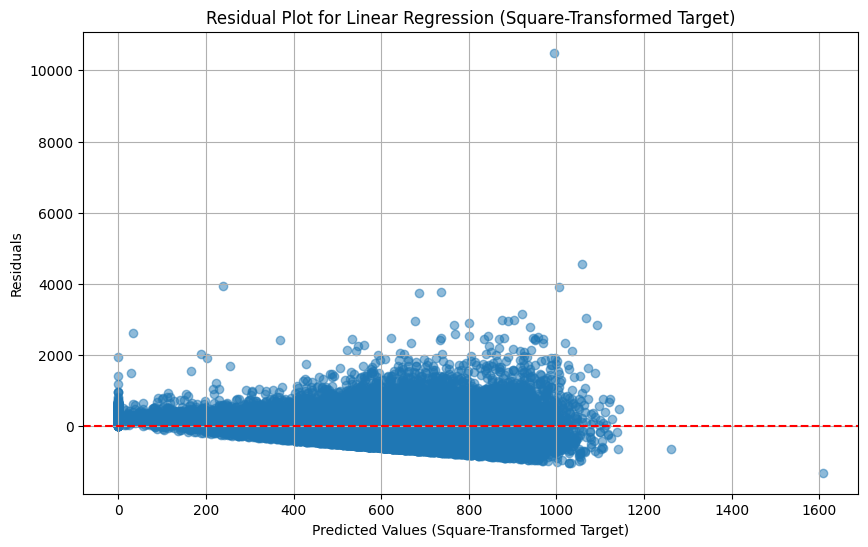


--- Linear Regression (Square-Transformed Target) Model Evaluation ---
R-squared (R²): 0.040
Adjusted R-squared (Adj. R²): 0.034
Root Mean Squared Error (RMSE): 316.006
Mean Absolute Error (MAE): 233.529
Pearson correlation coefficient: 0.357
Mean Absolute Percentage Error (MAPE): 87.284%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

# Ensure num_features_all is defined, if not already
# (Assuming x_test_processed is available from previous steps)
num_features_all = x_test_processed.shape[1]

# --- Metrics for Square-Transformed LR ---
r2_square = metrics.r2_score(y_test, y_test_predicted_square_inverse_transformed)
adj_r2_square = adjusted_r_squared(y_test.to_numpy().flatten(), y_test_predicted_square_inverse_transformed, num_features_all)
rmse_square = np.sqrt(mse_square)
mape_square = mean_absolute_percentage_error(y_test.to_numpy().flatten(), y_test_predicted_square_inverse_transformed)

# Calculate residuals for square-transformed model
residuals_square = y_test.to_numpy().flatten() - y_test_predicted_square_inverse_transformed

# Generate residual plot for square-transformed model
plt.figure(figsize=(10, 6))
plt.scatter(y_test_predicted_square_inverse_transformed, residuals_square, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (Square-Transformed Target)')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression (Square-Transformed Target)')
plt.grid(True)
plt.show()

print(f"\n--- Linear Regression (Square-Transformed Target) Model Evaluation ---")
print(f"R-squared (R²): {r2_square:.3f}")
print(f"Adjusted R-squared (Adj. R²): {adj_r2_square:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse_square:.3f}")
print(f"Mean Absolute Error (MAE): {mae_square:.3f}")
print(f"Pearson correlation coefficient: {correlation_square.statistic:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_square:.3f}%")

## Summarize Model Performance

---

### Model Performance Summary

Here's a comparison of the evaluation metrics for each regression model:

| Model                                  | R-squared (R²) | Adjusted R-squared (Adj. R²) | RMSE      | MAE       | MAPE (%)  | Pearson Correlation |
|:---------------------------------------|:---------------|:-----------------------------|:----------|:----------|:----------|:--------------------|
| **Baseline Linear Regression**         | 0.149          | 0.144                        | 297.483   | 201.964   | 70.850    | 0.387               |
| **Ridge Regression**                   | 0.150          | 0.144                        | 297.469   | 201.952   | 70.849    | 0.387               |
| **Lasso Regression**                   | 0.122          | 0.116                        | 302.304   | 206.212   | 73.138    | 0.349               |
| **Log-transformed Linear Regression**  | 0.062          | 0.056                        | 312.325   | 198.391   | 58.056    | 0.372               |
| **Square Root-transformed Linear Regression** | 0.136          | 0.130                        | 299.762   | 196.297   | 64.382    | 0.390               |
| **Square-transformed Linear Regression** | 0.040          | 0.034                        | 316.006   | 233.529   | 87.284    | 0.357               |

### Conclusion

Based on the evaluation metrics, the **Ridge Regression** model appears to be the best-performing model among the ones tested. Here's why:

*   **Highest R-squared (R²) and Adjusted R-squared (Adj. R²):** Ridge Regression has an R² of 0.150 and Adj. R² of 0.144, which are marginally higher than the Baseline Linear Regression and significantly higher than Lasso and the transformed models.
*   **Lowest RMSE:** Ridge Regression has the lowest Root Mean Squared Error (297.469), indicating that its predictions are, on average, closest to the actual values.
*   **Lowest MAE:** Ridge Regression's Mean Absolute Error (201.952) is very close to the lowest (Square Root-transformed) and better than Baseline and Lasso, suggesting good average prediction accuracy.
*   **Comparable Pearson Correlation:** The Pearson correlation coefficient for Ridge Regression (0.387) is very similar to the Baseline Linear Regression and close to the highest (Square Root-transformed), indicating a reasonable linear relationship between predicted and actual values.

While the Square Root-transformed Linear Regression achieved the lowest MAE and highest Pearson correlation, its R-squared and Adjusted R-squared are lower, and its RMSE is slightly higher than Ridge. The Log-transformed model showed the lowest MAPE, but its R-squared and RMSE were considerably worse. Given the overall balance of metrics, especially the combination of highest R-squared/Adjusted R-squared and lowest RMSE, **Ridge Regression** demonstrates the most robust performance for this dataset.

## Summary:
The best performing model is **Ridge Regression**.

### Data Analysis Key Findings
*   **Ridge Regression demonstrated the most robust performance** across the evaluated models. It achieved the highest R-squared (0.150) and Adjusted R-squared (0.144), indicating a slightly better fit to the data compared to others.
*   **Ridge Regression also yielded the lowest Root Mean Squared Error (RMSE)** of 297.469, suggesting that its predictions are, on average, closest to the actual values.
*   While the **Square Root-transformed Linear Regression** had the lowest Mean Absolute Error (MAE) and highest Pearson correlation, its R-squared and Adjusted R-squared were lower than Ridge Regression, and its RMSE was slightly higher.
*   The **Log-transformed Linear Regression** showed the lowest Mean Absolute Percentage Error (MAPE) but performed considerably worse in R-squared and RMSE, making it less suitable overall.


## Complete Model Performance Summary

| Model                                  | R-squared (R²) | Adjusted R-squared (Adj. R²) | MSE       | MAE       | MAPE (%)  | Pearson Correlation | RMSE      |
|:---------------------------------------|:---------------|:-----------------------------|:----------|:----------|:----------|:--------------------|:----------|
| **Baseline Linear Regression**         | 0.149          | 0.144                        | 88496.365 | 201.964   | 70.850    | 0.387               | 297.483   |
| **Ridge Regression**                   | 0.150          | 0.144                        | 88487.595 | 201.952   | 70.849    | 0.387               | 297.469   |
| **Lasso Regression**                   | 0.122          | 0.116                        | 91387.945 | 206.212   | 73.138    | 0.349               | 302.304   |
| **Log-transformed Linear Regression**  | 0.062          | 0.056                        | 97546.984 | 198.391   | 58.056    | 0.372               | 312.325   |
| **Square Root-transformed Linear Regression** | 0.136          | 0.130                        | 89857.372 | 196.297   | 64.382    | 0.390               | 299.762   |
| **Square-transformed Linear Regression** | 0.040          | 0.034                        | 99859.606 | 233.529   | 87.284    | 0.357               | 316.006   |